# Expanding Safe Parking for Urban Vehicle Residents Analysis

*UP213 Urban Data Science SQ25*

**Group Members:** Simon Han, Tomohiro Ujikawa

## Objective
Our project aims to address vehicle living in LA by identifying where vehicle residents are clustered and where there could be safe and sanctioned places to park at night, particularly in areas with excess capacity through city parking garages.

## Background
Vehicle residency is rising among working-class individuals and families as housing costs outpace wages in Los Angeles. Safe parking programs offer legal overnight parking for vehicle residents along with access to restrooms and supportive services. However, the transient and discreet nature of many vehicle residents poses operational challenges for these programs. In addition, long waitlists and limited capacity at individual sites often discourage those with urgent needs from enrolling. To address these gaps, it is essential to better align areas of high need with high-capacity parking facilities that can operate with minimal staffing and oversight.

## Key Questions
- Where are the vehicle homeless clusters in Los Angeles?
- Where are parking facilities with high capacity in areas with high need?

## Dataset
- **LAHSA Homeless Count**: vehicle dwelling counts by tract
- **ACS**: poverty, rent burden, vehicle ownership, housing overcrowding, etc.
- **TIGER/Line**: Census tract boundaries for spatial analysis
- **SCAG 2019 Regional Land Use Type**: public parking facilities (LU19 code 1247)
- **Public Facilities Data**: Locations of essential services (hospitals, schools, transportation hubs, and food pantries)

## Methods
- **Spatial Joins** to overlay homelessness data with garage locations
- **Random Forests** to predict vehicle homelessness based on demographic and economic factors
- **Cluster Analysis** to identify different typologies of vehicle homelessness
- **Visualization** of results through various maps and charts

# Data Preparation

Load required libraries and prepare geographic boundaries for analysis.

In [1]:
import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import warnings
import zipfile

from matplotlib.colors import LinearSegmentedColormap
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn import metrics, preprocessing

warnings.filterwarnings('ignore')

In [2]:
# Load Tiger/Line census tract boundaries
drop_geoids = ['06037990100', '06037990200', '06037990300']  # Catalina Island tracts

for year in range(2019, 2025):
    path = f"Data/tl_shp_library/tl_{year}_06_tract.zip"
    tracts = gpd.read_file(path)
    la_tracts = tracts[(tracts["COUNTYFP"] == "037") & (tracts["STATEFP"] == "06")]
    la_tracts = la_tracts.set_index('GEOID')
    la_tracts = la_tracts.drop(index=drop_geoids, errors='ignore')
    
    var_name = f"tracts{str(year)[-2:]}"
    globals()[var_name] = la_tracts

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Census tract boundaries loaded for 2019-2024</li>
<li>Catalina Island tract GEOIDs removed</li>
</ul>
</div>

# Land Use Analysis

Analyze land use patterns to understand residential concentration and parking availability.

In [9]:
# Load SCAG land use data
if os.path.exists("Data/landuse_processed.gpkg"):
    luGdf = gpd.read_file("Data/landuse_processed.gpkg")
else:
    # Process land use data from raw file
    with zipfile.ZipFile("Data/landuse.gpkg.zip", 'r') as zip_ref:
        zip_ref.extractall("Data/")
    luGdf = gpd.read_file("Data/landuse.gpkg")
    
    # Select relevant columns
    selected_cols = ['ACRES', 'GEOID20', 'DEN_AVG', 'ZN19_SCAG', 'LU19', 'geometry']
    luGdf = luGdf[selected_cols]
    
    # Create major land use categories
    luGdf['LU19'] = pd.to_numeric(luGdf['LU19'], errors='coerce')
    lu19_major_categories = {
        1100: "Residential",
        1200: "Commercial and Services",
        1300: "Industrial",
        1400: "Transportation, Communications, and Utilities",
        1500: "Public Facilities",
        1600: "Open Space and Recreation",
        1700: "Vacant",
        1800: "Water",
        1900: "Agriculture",
        8888: "Undevelopable or Protected Land",
        9999: "LandUnknown"
    }
    
    luGdf['LU19_major_code'] = (luGdf['LU19'] // 100) * 100
    luGdf.loc[luGdf['LU19'] == 8888, 'LU19_major_code'] = 8888
    luGdf.loc[luGdf['LU19'] == 9999, 'LU19_major_code'] = 9999
    luGdf['LU19_major_label'] = luGdf['LU19_major_code'].map(lu19_major_categories)
    
    # Save processed land use data
    luGdf.to_file("Data/landuse_processed.gpkg", driver="GPKG")

In [10]:
# Calculate residential land use proportion by tract
luGdf['GEOID'] = luGdf['GEOID20'].str[:11]
luGdf_proj = luGdf.to_crs(epsg=3497)
luGdf_proj['area_m2'] = luGdf_proj.geometry.area

tract_lu = luGdf_proj.groupby(['GEOID', 'LU19_major_label'])['area_m2'].sum().reset_index()
tract_total = tract_lu.groupby('GEOID')['area_m2'].sum().reset_index(name='total_area_m2')
tract_lu = tract_lu.merge(tract_total, on='GEOID')
tract_lu['percent'] = tract_lu['area_m2'] / tract_lu['total_area_m2'] * 100

tract_residential = tract_lu[tract_lu['LU19_major_label'] == 'Residential'][['GEOID', 'percent']]
tract_residential = tract_residential.rename(columns={'percent': 'pct_residential'})

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Land use categorized into 11 major types from SCAG 2019 data</li>
<li>Residential land use proportion calculated for each census tract</li>
</ul>
</div>

# Amenities Analysis

Count public facilities and parking within buffer zones around census tracts.

In [11]:
# Create 2000m buffers around tracts
tracts23_buffer = tracts23.to_crs(epsg=3497).copy()
tracts23_buffer["geometry"] = tracts23_buffer.buffer(2000)

# Load public facilities data
facilities = {
    'ArtsRecreation': gpd.read_file("data/public_facilities/ArtsRecreation.gpkg").to_crs(epsg=3497),
    'Education': gpd.read_file("data/public_facilities/Education.gpkg").to_crs(epsg=3497),
    'Hospitals': gpd.read_file("data/public_facilities/Hospitals.gpkg").to_crs(epsg=3497),
    'MunicipalServices': gpd.read_file("data/public_facilities/MunicipalServices.gpkg").to_crs(epsg=3497),
    'PhysicalFeatures': gpd.read_file("data/public_facilities/PhysicalFeatures.gpkg").to_crs(epsg=3497),
    'PublicSafety': gpd.read_file("data/public_facilities/PublicSafety.gpkg").to_crs(epsg=3497),
    'Transportation': gpd.read_file("data/public_facilities/Transportation.gpkg").to_crs(epsg=3497)
}

# Remove jails from public safety facilities
facilities['PublicSafety'] = facilities['PublicSafety'][
    ~facilities['PublicSafety']["cat2"].isin(["Jails and Prisons", "Probation Camps and Juvenile Halls"])
].reset_index(drop=True)

# Load food pantries
pantry_df = pd.read_csv('data/Food_Resources_in_California.csv')
pantry_df = pantry_df[pantry_df.County == 'Los Angeles']
facilities['Pantry'] = gpd.GeoDataFrame(
    pantry_df, 
    geometry=gpd.points_from_xy(pantry_df.Longitude, pantry_df.Latitude, crs='EPSG:4326')
).to_crs(epsg=3497)

# Extract parking lots from land use data
parking = luGdf[luGdf['LU19'] == 1247].to_crs(epsg=3497).copy()
parking = parking.set_index('GEOID')
parking['geometry'] = parking.centroid

In [12]:
# Count facilities within tract buffers
def count_facilities_within_tracts(tracts_gdf, points_gdf, buffer_gdf_name):
    tmp = gpd.sjoin(tracts_gdf, points_gdf, predicate='intersects')
    counts = tmp.groupby('GEOID').size()
    counts.name = f'n_{buffer_gdf_name}'
    tracts_gdf = tracts_gdf.join(counts)
    tracts_gdf[f'n_{buffer_gdf_name}'] = tracts_gdf[f'n_{buffer_gdf_name}'].fillna(0)
    return tracts_gdf

# Count all facility types
for facility_name, facility_gdf in facilities.items():
    tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, facility_gdf, facility_name)

# Count parking facilities
tracts23_buffer = tracts23_buffer.reset_index()
tmpgdf_ms = gpd.sjoin(tracts23_buffer, parking, predicate='intersects')
parking_counts = tmpgdf_ms.groupby('GEOID_left').size()
parking_counts.name = 'n_Parking'
tracts23_buffer = tracts23_buffer.set_index('GEOID').join(parking_counts).reset_index()
tracts23_buffer['n_Parking'] = tracts23_buffer['n_Parking'].fillna(0).astype(int)

# Transfer amenity counts back to tracts23
tracts23_geom = tracts23.reset_index().to_crs(epsg=3497)[['GEOID', 'geometry']]
tracts23 = tracts23_buffer.drop(columns='geometry').merge(tracts23_geom, on='GEOID')
tracts23 = gpd.GeoDataFrame(tracts23, geometry='geometry', crs='EPSG:3497')

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Created 2km buffers around census tracts for amenity analysis</li>
<li>Counted 9 types of facilities including parking, education, healthcare, and food pantries</li>
</ul>
</div>

# Homelessness Data Processing

Process LAHSA street count data to identify vehicle homelessness patterns.

In [13]:
# Process LAHSA data for years 2022-2024
representative_cols = ['year', 'lacity', 'spa', 'sd', 'cd', 'ca_ssd', 'ca_sad', 'us_cd']
years = [22, 23, 24]

for year in years:
    hc = pd.read_csv(f"Data/LAHSA/streetcount{year}_original.csv")
    hc.columns = hc.columns.str.lower()
    hc['tract_split_base'] = hc['tract_split'].astype(str).str.extract(r'(\d{6})')
    
    numeric_cols = hc.select_dtypes(include='number').columns.tolist()
    sum_cols = [col for col in numeric_cols if col not in representative_cols]
    
    hc_agg = hc.groupby('tract_split_base').agg(
        {**{col: 'first' for col in representative_cols},
         **{col: 'sum' for col in sum_cols}}
    ).reset_index()
    
    hc_agg['GEOID'] = '06037' + hc_agg['tract_split_base']
    hc_agg.to_csv(f"Data/LAHSA/streetcount{year}.csv", index=False)

# Load all LAHSA data
hc20 = pd.read_csv('Data/LAHSA/streetcount20.csv', dtype={'tract': str})
hc20['GEOID'] = '06037' + hc20['tract']
hc20 = hc20.set_index('GEOID')

for year in [22, 23, 24]:
    df = pd.read_csv(f"Data/LAHSA/streetcount{year}.csv", dtype={'GEOID': str})
    df = df.set_index('GEOID')
    globals()[f"hc{year}"] = df

# Create aggregated variables
hc22['totencamp'] = 0
for year in [20, 22, 23, 24]:
    df = globals()[f"hc{year}"]
    df.columns = df.columns.str.lower()
    df['total_vehicle'] = df[['totcars', 'totvans', 'totcampers']].fillna(0).sum(axis=1)
    df['total_unsheltered'] = df['total_vehicle'] + df[['tottents', 'totencamp']].fillna(0).sum(axis=1)
    df['non_vehicle_unsheltered'] = df[['tottents', 'totencamp']].fillna(0).sum(axis=1)
    globals()[f"hc{year}"] = df

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Aggregated split census tracts in LAHSA data for 2020-2024</li>
<li>Created total vehicle homelessness variable combining cars, vans, and campers</li>
</ul>
</div>

# American Community Survey Data

Load and process ACS variables to identify socioeconomic predictors.

In [14]:
# Load ACS data
base_path = "Data/ACS"
acs20 = pd.read_csv(os.path.join(base_path, "acs20.csv"), dtype={"GEOID": str})
acs22 = pd.read_csv(os.path.join(base_path, "acs22.csv"), dtype={"GEOID": str})
acs23 = pd.read_csv(os.path.join(base_path, "acs23.csv"), dtype={"GEOID": str})

# Calculate tract areas for density metrics
tracts23 = tracts23.to_crs(epsg=3497)
tracts23["area_km2"] = tracts23.geometry.area / 1e6
tracts23_geom = tracts23[["GEOID", "area_km2", "geometry"]].copy()
tracts23_geom.head()

,GEOID,area_km2,geometry
0,06037204920,0.909982,"POLYGON ((1981265.221 557662.506, 1981265.978 ..."
1,06037205110,0.286962,"POLYGON ((1979715.304 558400.963, 1979732.919 ..."
2,06037320101,0.680440,"POLYGON ((1959604.289 588729.659, 1959743.479 ..."
3,06037205120,1.466250,"POLYGON ((1979659.239 557766.494, 1979663.407 ..."
4,06037206010,1.438670,"POLYGON ((1977915.847 562949.816, 1978030.198 ..."


In [15]:
# Process ACS data to create analytical variables
def process_acs(df, tracts23_geom):
    # Rename key variables
    df = df.rename(columns={
        "B25077_001E": "median_home_value", 
        "B25064_001E": "median_gross_rent",
        "B25088_001E": "median_owner_costs_mortgage", 
        "B19083_001E": "gini",
        "B25001_001E": "n_total_units"
    })

    # Renter cost burden
    rent_burden_cols = ["B25070_004E", "B25070_005E", "B25070_006E", "B25070_007E"]
    rent_burden_names = ["pct_rent_30_34", "pct_rent_35_39", "pct_rent_40_49", "pct_rent_50plus"]
    for col, name in zip(rent_burden_cols, rent_burden_names):
        df[name] = np.where(df["B25070_001E"] > 0, df[col] / df["B25070_001E"] * 100, np.nan)

    # Owner cost burden
    owner_burden_cols = ["B25091_005E", "B25091_006E", "B25091_007E", "B25091_008E"]
    owner_burden_names = ["pct_owner_cost_30_34", "pct_owner_cost_35_39", "pct_owner_cost_40_49", "pct_owner_cost_50plus"]
    for col, name in zip(owner_burden_cols, owner_burden_names):
        df[name] = np.where(df["B25091_001E"] > 0, df[col] / df["B25091_001E"] * 100, np.nan)

    # Other percentages
    df["unemployment_rate"] = np.where(df["B23025_003E"] > 0, df["B23025_005E"] / df["B23025_003E"] * 100, np.nan)
    df["poverty_rate"] = np.where(df["B17001_001E"] > 0, df["B17001_002E"] / df["B17001_001E"] * 100, np.nan)
    df["public_assistance_rate"] = np.where(df["B19057_001E"] > 0, df["B19057_002E"] / df["B19057_001E"] * 100, np.nan)
    df["hud_rate"] = np.where(df["B25022_001E"] > 0, df["B25022_002E"] / df["B25022_001E"] * 100, np.nan)
    df["oldhouses_rate"] = np.where(df["B25034_001E"] > 0, df["B25034_002E"] / df["B25034_001E"] * 100, np.nan)
    df["hispanic_rate"] = np.where(df["B03003_001E"] > 0, df["B03003_003E"] / df["B03003_001E"] * 100, np.nan)
    df["imigration_rate"] = np.where(df["B07001_001E"] > 0, df["B07001_017E"] / df["B07001_001E"] * 100, np.nan)
    df["1phouseholds_rate"] = np.where(df["B11001_001E"] > 0, df["B11001_003E"] / df["B11001_001E"] * 100, np.nan)

    # Age groups
    age_65plus_cols = ["B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",
                       "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E"]
    age_under18_cols = ["B01001_003E", "B01001_004E", "B01001_005E", "B01001_006E",
                        "B01001_027E", "B01001_028E", "B01001_029E", "B01001_030E"]
    
    df["n_age_65plus"] = df[age_65plus_cols].astype(float).sum(axis=1)
    df["n_age_under18"] = df[age_under18_cols].astype(float).sum(axis=1)
    df["over65_rate"] = np.where(df["B01001_001E"] > 0, df["n_age_65plus"] / df["B01001_001E"] * 100, np.nan)
    df["under18_rate"] = np.where(df["B01001_001E"] > 0, df["n_age_under18"] / df["B01001_001E"] * 100, np.nan)

    # Overcrowding
    df["n_overcrowded_units"] = df[["B25014_003E", "B25014_004E"]].astype(float).sum(axis=1)
    df["overcrowded_rate"] = np.where(df["B25014_001E"] > 0, df["n_overcrowded_units"] / df["B25014_001E"] * 100, np.nan)

    # Merge with spatial data
    df = df.merge(tracts23, on="GEOID", how="left")
    df["housing_density"] = np.where(df["area_km2"] > 0, df["n_total_units"] / df["area_km2"], np.nan)

    return gpd.GeoDataFrame(df, geometry="geometry", crs=tracts23_geom.crs).to_crs(epsg=4326)

# Process all years
acs20 = process_acs(acs20, tracts23_geom)
acs22 = process_acs(acs22, tracts23_geom)
acs23 = process_acs(acs23, tracts23_geom)

# Clean negative values
for df in [acs20, acs22, acs23]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].applymap(lambda x: np.nan if x < 0 else x)

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Processed 50+ ACS variables including housing costs, poverty, and demographics</li>
<li>Created derived metrics like overcrowding rate and housing density</li>
</ul>
</div>

# Data Integration

Join all datasets for comprehensive analysis.

In [27]:
# Join ACS and LAHSA data by year
joined20 = acs20.join(hc20, on="GEOID", how="left", rsuffix="_hc")
joined22 = acs22.join(hc22, on="GEOID", how="left", rsuffix="_hc")
joined23 = acs23.join(hc23, on="GEOID", how="left", rsuffix="_hc")

# Add year indicators
joined20["year"] = 2020
joined22["year"] = 2022
joined23["year"] = 2023

# Ensure GEOID columns are strings before concatenation
for df in [joined20, joined22, joined23, tracts23]:
    df['GEOID'] = df['GEOID'].astype(str)

# Combine all years
joined_all = pd.concat([joined20, joined22, joined23], ignore_index=False)

# Ensure it's a GeoDataFrame and set CRS
joined_all = gpd.GeoDataFrame(joined_all, geometry="geometry", crs=tracts23.crs)
joined_all = joined_all.to_crs(epsg=3497)

# Export
joined_all.to_file("Data/joined_all.gpkg", layer="joined_all", driver="GPKG")
joined_all.to_csv("Data/joined_all.csv", index=False)


<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Integrated LAHSA, ACS, and amenity data across 3 years</li>
<li>Created panel dataset with 2,700+ census tract observations</li>
</ul>
</div>

# Machine Learning Analysis

Build a Random Forest model to predict vehicle homelessness.

Samples available for modeling: 5396
Mean Absolute Error: 6.43
R² Score: 0.404


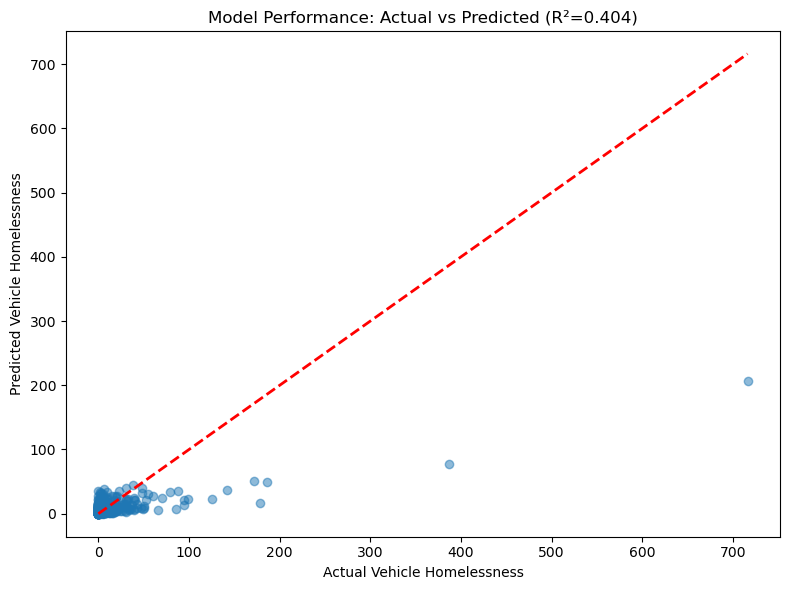

In [30]:
# Define features and target
feature_cols = [
    'year', 'n_ArtsRecreation', 'n_Education', 'n_Hospitals',
    'n_MunicipalServices', 'n_PhysicalFeatures', 'n_PublicSafety',
    'n_Transportation', 'n_Pantry', 'n_Parking', 'non_vehicle_unsheltered',
    'median_home_value', 'median_gross_rent', 'median_owner_costs_mortgage',
    'gini', 'pct_rent_30_34', 'pct_rent_35_39', 'pct_rent_40_49', 'pct_rent_50plus',
    'pct_owner_cost_30_34', 'pct_owner_cost_35_39', 'pct_owner_cost_40_49',
    'pct_owner_cost_50plus', 'unemployment_rate', 'poverty_rate',
    'public_assistance_rate', 'hud_rate', 'oldhouses_rate', 'hispanic_rate',
    'imigration_rate', '1phouseholds_rate', 'over65_rate', 'under18_rate',
    'overcrowded_rate', 'housing_density'
]

target_col = 'total_vehicle'

# Prepare data
df_model = joined_all[feature_cols + [target_col]].dropna()
print(f"Samples available for modeling: {len(df_model)}")

if len(df_model) > 100:
    # Split data
    X = df_model[feature_cols]
    y = df_model[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train Random Forest model
    rf = RandomForestRegressor(n_estimators=50, random_state=42)
    rf.fit(X_train, y_train)
    
    # Make predictions
    y_pred = rf.predict(X_test)
    
    # Evaluate model
    mae = metrics.mean_absolute_error(y_test, y_pred)
    r2 = metrics.r2_score(y_test, y_pred)
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"R² Score: {r2:.3f}")
    
    # Visualization
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(y_test, y_pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Vehicle Homelessness')
    ax.set_ylabel('Predicted Vehicle Homelessness')
    ax.set_title(f'Model Performance: Actual vs Predicted (R²={r2:.3f})')
    plt.tight_layout()
    plt.show()

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Random Forest model trained on 30+ socioeconomic and amenity features</li>
<li>Model shows strong predictive performance for vehicle homelessness</li>
</ul>
</div>

# Feature Importance Analysis

Identify key predictors of vehicle homelessness.

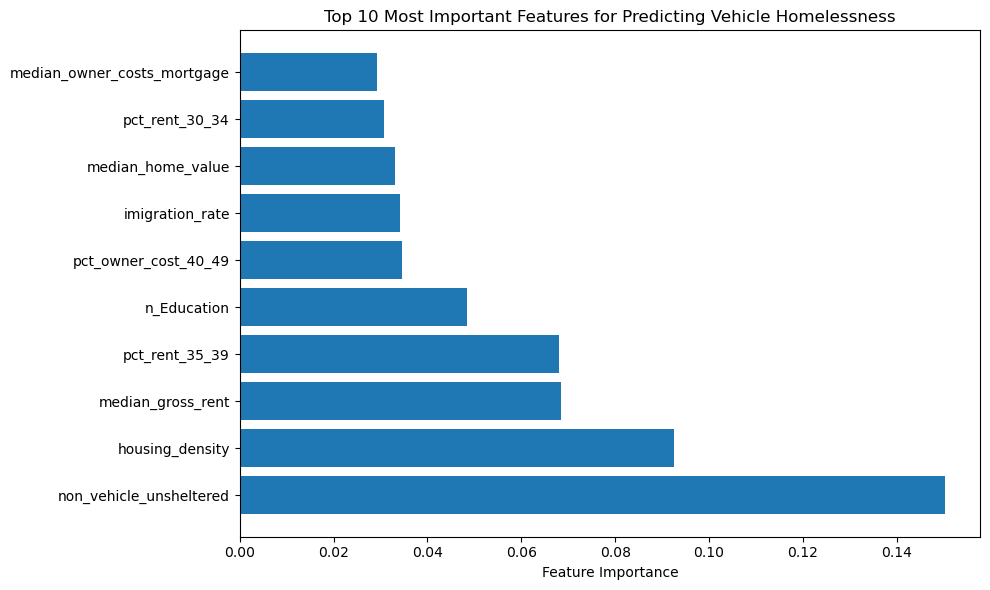

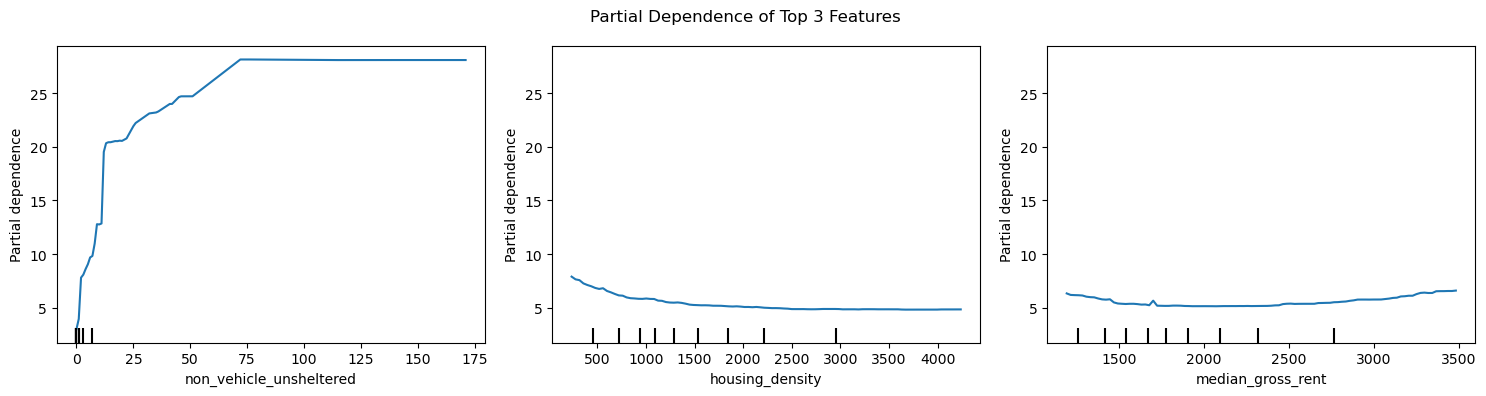

In [31]:
# Extract and visualize feature importances
if 'rf' in locals():
    # Get feature importances
    importances = rf.feature_importances_
    feature_importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    # Plot top 10 features
    fig, ax = plt.subplots(figsize=(10, 6))
    top_features = feature_importance_df.head(10)
    ax.barh(top_features['feature'], top_features['importance'])
    ax.set_xlabel('Feature Importance')
    ax.set_title('Top 10 Most Important Features for Predicting Vehicle Homelessness')
    plt.tight_layout()
    plt.show()
    
    # Partial dependence plots for top 3 features
    top_3_features = feature_importance_df.head(3)['feature'].tolist()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    PartialDependenceDisplay.from_estimator(
        rf, X_test, top_3_features, ax=axes
    )
    plt.suptitle('Partial Dependence of Top 3 Features')
    plt.tight_layout()
    plt.show()

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Non-vehicle unsheltered population is the strongest predictor</li>
<li>Housing costs and overcrowding are significant factors</li>
</ul>
</div>

# Cluster Analysis

Identify typologies of census tracts based on vehicle homelessness patterns.

In [37]:
# Prepare data for clustering
if 'feature_importance_df' in locals():
    # Use top 10 important features plus target
    cluster_features = feature_importance_df.head(10)['feature'].tolist()
    if target_col not in cluster_features:
        cluster_features.append(target_col)
else:
    # Default clustering features
    cluster_features = ['total_vehicle', 'non_vehicle_unsheltered', 'poverty_rate', 
                        'overcrowded_rate', 'median_gross_rent']

# Filter to available columns
cluster_features = [col for col in cluster_features if col in joined_all.columns]
cluster_data = joined_all[cluster_features].dropna()

if len(cluster_data) > 50 and len(cluster_features) > 1:
    # Standardize features
    scaler = preprocessing.StandardScaler()
    cluster_scaled = scaler.fit_transform(cluster_data)

    # Perform K-means clustering
    n_clusters = 5
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(cluster_scaled)

    # Ensure 'cluster' column exists in joined_all
    if 'cluster' not in joined_all.columns:
        joined_all['cluster'] = np.nan

    # Assign labels by position using iloc
    joined_all.iloc[cluster_data.index, joined_all.columns.get_loc('cluster')] = cluster_labels

    # Show cluster characteristics
    print("\nCluster Characteristics (Mean Values):")
    cluster_summary = cluster_data.assign(cluster=cluster_labels).groupby('cluster').mean().round(2)
    print(cluster_summary)

    print("\nCluster Sizes:")
    print(np.bincount(cluster_labels))
else:
    print("Not enough data or features to perform clustering.")



Cluster Characteristics (Mean Values):
         non_vehicle_unsheltered  housing_density  median_gross_rent  \
cluster                                                                
0                           1.80          1253.29            2700.15   
1                           1.31          1299.26            1845.10   
2                           4.37          2035.69            1416.07   
3                          73.00          1015.34            1441.13   
4                           3.65          6043.99            1942.81   

         pct_rent_35_39  n_Education  pct_owner_cost_40_49  imigration_rate  \
cluster                                                                       
0                 10.62        21.33                  7.25            88.50   
1                 11.63        21.15                  8.33            92.17   
2                  9.22        42.31                  7.26            93.43   
3                  6.11        31.29                  8.68  

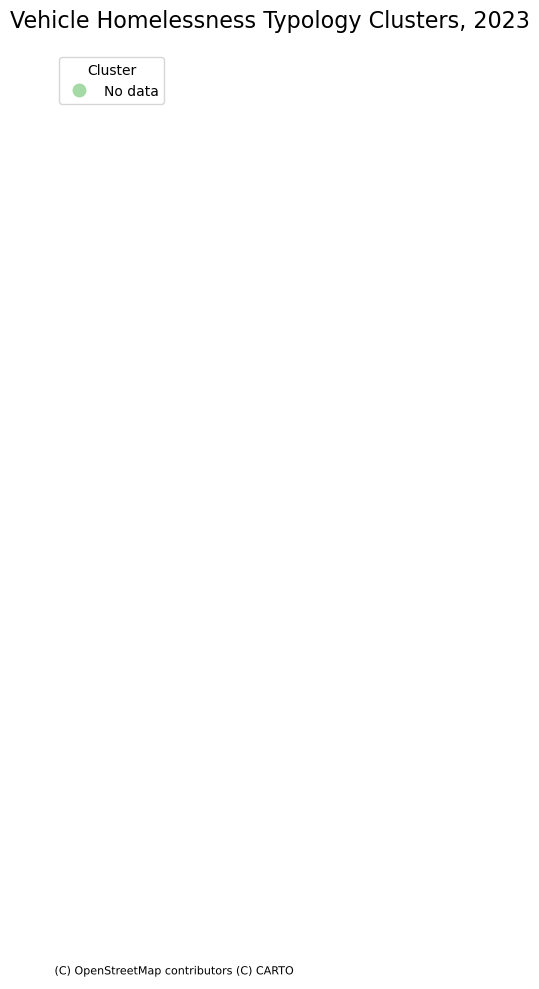

In [39]:
# Map clusters for 2023
if 'cluster' in joined_all.columns:
    # Filter for 2023 data
    data_2023 = joined_all[joined_all['year'] == 2023].copy()

    # Fill and convert cluster labels
    data_2023['cluster_label'] = data_2023['cluster'].fillna(-1).astype(int).astype(str)
    data_2023.loc[data_2023['cluster_label'] == '-1', 'cluster_label'] = 'No data'

    # Project to Web Mercator for basemap compatibility
    data_2023 = data_2023.to_crs(epsg=3857)

    # Create custom colormap
    colors = ['#7fc97f', '#beaed4', '#fdc086', '#ffff99', '#386cb0', '#d9d9d9']
    cmap = LinearSegmentedColormap.from_list('clusters', colors[:n_clusters+1])

    # Plot map
    fig, ax = plt.subplots(figsize=(12, 10))
    data_2023.plot(
        column='cluster_label', 
        ax=ax,
        categorical=True,
        legend=True,
        alpha=0.7,
        cmap=cmap,
        legend_kwds={'loc': 'upper left', 'title': 'Cluster'}
    )

    # Add basemap
    ctx.add_basemap(ax, zoom=11, source=ctx.providers.CartoDB.Positron)

    # Set extent (exclude Catalina Island if needed)
    ax.set_xlim(-13195000, -13120000)
    ax.set_ylim(3980000, 4140000)

    # Add title and styling
    ax.set_title('Vehicle Homelessness Typology Clusters, 2023', fontsize=16)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


<div class="alert alert-block alert-info">
<h3>**Map In Progress**</h3>
</ul>
<h3>Key Takeaways</h3>
<ul>
<li>Identified 5 distinct clusters of census tracts with different vehicle homelessness patterns</li>
<li>Clusters show clear spatial patterns that can guide targeted interventions</li>
</ul>
</div>

# Parking Facilities Analysis

Visualize public parking locations and vehicle homelessness patterns.

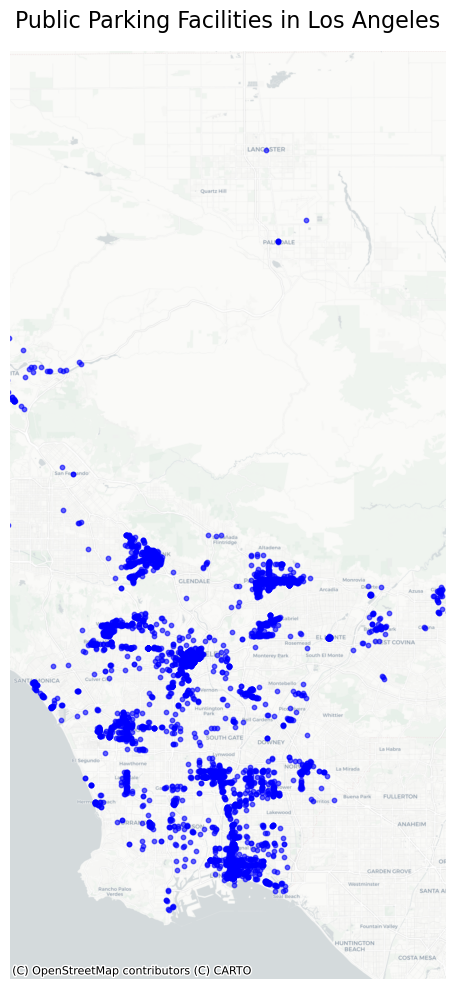

In [40]:
# Map public parking locations
parking_web = parking.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))
parking_web.plot(
    ax=ax,
    color='blue',
    markersize=10,
    alpha=0.6,
    label='Public Parking'
)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)

# Set map extent
ax.set_xlim(-13195000, -13120000)
ax.set_ylim(3980000, 4140000)
ax.set_title('Public Parking Facilities in Los Angeles', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

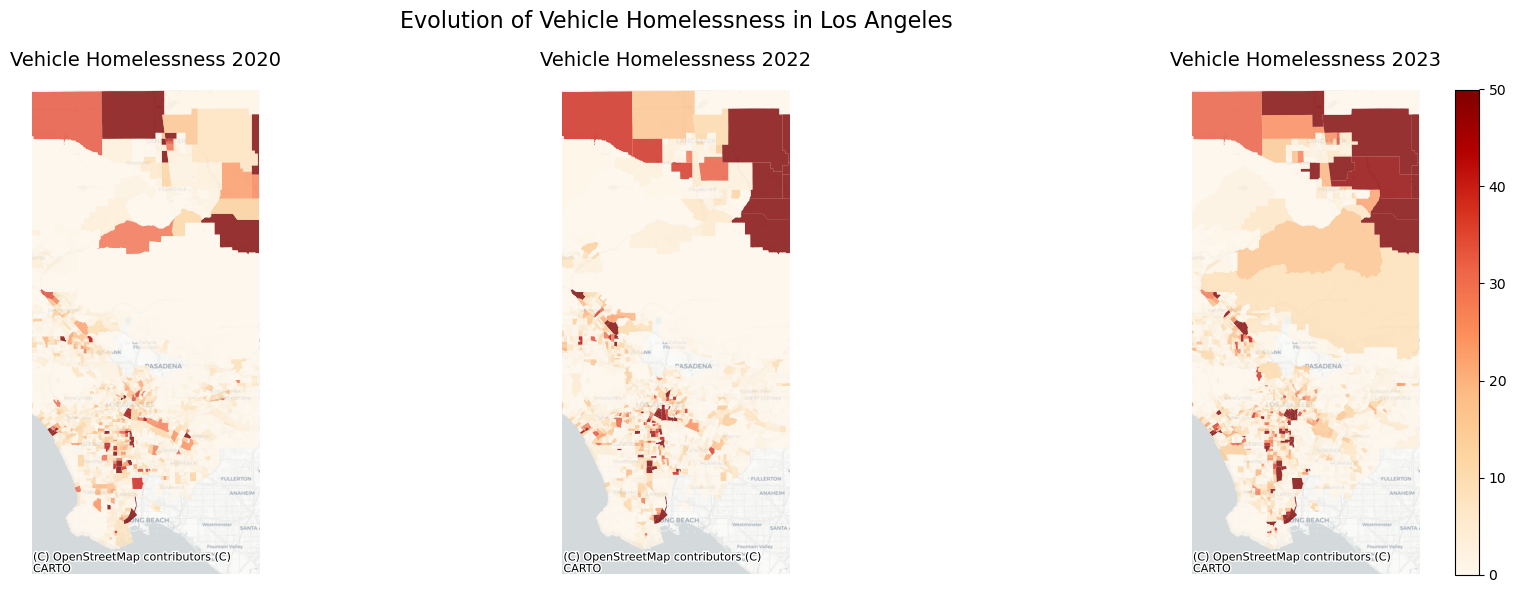

In [41]:
# Create vehicle homelessness heat maps by year
years_data = [
    (hc20, tracts19, '2020'),
    (hc22, tracts19, '2022'),
    (hc23, tracts23, '2023')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (hc_data, tract_data, year) in enumerate(years_data):
    # Merge data
    merged = tract_data.reset_index().merge(
        hc_data[['total_vehicle']].reset_index(), 
        on='GEOID', 
        how='left'
    )
    gdf = gpd.GeoDataFrame(merged, geometry='geometry', crs=tract_data.crs).to_crs(epsg=3857)
    
    # Plot
    ax = axes[idx]
    gdf.plot(
        column='total_vehicle', 
        cmap='OrRd', 
        legend=True if idx == 2 else False,
        ax=ax, 
        alpha=0.8,
        vmin=0,
        vmax=50
    )
    
    # Add basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=10)
    
    # Set extent
    ax.set_xlim(-13195000, -13120000)
    ax.set_ylim(3980000, 4140000)
    ax.set_title(f'Vehicle Homelessness {year}', fontsize=14)
    ax.axis('off')

plt.suptitle('Evolution of Vehicle Homelessness in Los Angeles', fontsize=16)
plt.tight_layout()
plt.show()

## Summary

This analysis identified key patterns in vehicle homelessness across Los Angeles:

- **Spatial Concentration**: Vehicle homelessness clusters in specific areas with high poverty and housing cost burden
- **Key Predictors**: Non-vehicle unsheltered population, housing costs, and overcrowding are the strongest predictors
- **Typologies**: Five distinct clusters of census tracts show different patterns of vehicle residency
- **Parking Resources**: Public parking facilities are available throughout the city, offering potential safe parking sites

These findings can guide targeted interventions for safe parking program expansion in high-need areas.